# 1) Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


# 2) Basic Data Manipulation

## 2.1) Importing data

In [2]:
data_folder = os.path.join(os.getcwd(), '..', 'data')
df_data = pd.read_csv(data_folder + '/raw/skill_builder_data.csv', encoding='ISO-8859-1', low_memory=False)
df_data.head()


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


## 2.2) Deleting unnecessary columns

In [3]:
columns_to_keep = ['order_id', 'user_id', 'correct', 'skill_id', 'skill_name', 'problem_id',
                              'ms_first_response', 'bottom_hint', 'hint_total', 'hint_count', 'opportunity']
df_data_filtered = df_data[columns_to_keep]
df_data_filtered.isna().sum()


order_id                  0
user_id                   0
correct                   0
skill_id              66326
skill_name            78690
problem_id                0
ms_first_response         0
bottom_hint          445627
hint_total                0
hint_count                0
opportunity               0
dtype: int64

## 2.3) Adding new features

In [4]:
df_data_full = df_data_filtered.dropna(subset='skill_id')

df_data_full = df_data_full.copy()

df_data_full['bottom_hint'] = df_data_full['bottom_hint'].fillna(0)

df_data_full['opportunity_padded'] = df_data_full['opportunity'].apply(lambda x: f"{int(x):04d}")

# Create the 'timestamp' column by concatenating 'order_id' and padded 'opportunity'
df_data_full['timestamp'] = df_data_full['order_id'].astype(str) + df_data_full['opportunity_padded']

df_data_full['hints_used'] = np.where(
    df_data_full['hint_total'] == 0,  # Condition: hint_total is 0
    0,                                # Value when true (set to 0)
    df_data_full['hint_count'] / df_data_full['hint_total']  # Normal division otherwise
)

df_data_full.drop(columns=['opportunity', 'opportunity_padded', 'order_id', 'hint_total', 'hint_count'], inplace=True)

df_data_full.head()


,user_id,correct,skill_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp,hints_used
0,64525,1,1.0,Box and Whisker,51424,32454,0.0,330225370001,0.00
1,64525,1,1.0,Box and Whisker,51435,4922,0.0,330227090002,0.00
2,70363,0,1.0,Box and Whisker,51444,25390,0.0,354502040001,0.00
3,70363,1,1.0,Box and Whisker,51395,4859,0.0,354502950002,0.00
4,70363,0,1.0,Box and Whisker,51481,19813,0.0,354503110003,0.75


## 2.4) Converting the datatypes

In [5]:
df_data_full.dtypes

user_id                int64
correct                int64
skill_id             float64
skill_name            object
problem_id             int64
ms_first_response      int64
bottom_hint          float64
timestamp             object
hints_used           float64
dtype: object

There are no trailing zeros in the ID columns, so we convert them to int.

In [9]:
df_data_full['skill_id'] = pd.to_numeric(df_data_full['skill_id'], errors='coerce').astype('Int64')
columns_to_int = ['user_id', 'correct', 'skill_id', 'problem_id', 'ms_first_response', 'bottom_hint']
df_data_full[columns_to_int] = df_data_full[columns_to_int].astype(int)

# Convert specific columns to string
columns_to_str = ['skill_name', 'timestamp']  # Replace with your column names
df_data_full[columns_to_str] = df_data_full[columns_to_str].astype(str)

df_data_sorted = df_data_full.sort_values(by=['user_id', 'timestamp'])
df_data_sorted.head()


,user_id,correct,skill_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp,hints_used
3957,14,0,2,Circle Graph,93383,26271,1,216176230001,1.0
94047,14,0,37,nan,93383,26271,1,216176230001,1.0
172411,14,0,70,Percent Of,93383,26271,1,216176230001,1.0
3958,14,1,2,Circle Graph,93407,29123,0,216176320002,0.0
94048,14,1,37,nan,93407,29123,0,216176320002,0.0


## 2.5) Deleting skill without a skill name attached

In [17]:
df_data_sorted = df_data_sorted[df_data_sorted['skill_name'] != 'nan']


## 2.6) Merging the 2 Absolute Value Skills

In [21]:
df_data_sorted['skill_id'] = df_data_sorted['skill_id'].replace(163, 85)


# 3) Complex Data Manipulation

## 3.1) Checking that every user made only one problem at once

In [22]:
# Group by 'user_id' and 'timestamp' and count the unique 'problem_id' values for each group
unique_problem_ids_count = df_data_sorted.groupby(['user_id', 'timestamp'])['problem_id'].nunique().reset_index(name='unique_problem_id_count')

# Display the result
unique_problem_ids_count['unique_problem_id_count'].unique()


array([1])

The check above means that correctly to one user-timestamp pair only one problem ID belongs.
IMPORTANT: An answer can appear multiple times if it belongs to multiple skills. We wan this be consistent, so the same answer ID should be present for all its skill IDs every time. Because of this, we break our data into 2 parts: user-answer and answer-skill sets.

## 3.2) Breaking the data into 2 parts

In [23]:
df_skill_problem_mapping = df_data_sorted[['skill_id', 'skill_name', 'problem_id']].drop_duplicates().sort_values(by='skill_id').reset_index(drop=True)
df_answers = df_data_sorted.drop(columns=['skill_id', 'skill_name']).drop_duplicates().reset_index(drop=True)
df_answers = df_answers.merge(df_skill_problem_mapping, on='problem_id')

cols = df_answers.columns.tolist()
cols[-1], cols[1] = cols[1], cols[-1]  # Swap second and last column positions
df_answers = df_answers[cols]  # Reorder the DataFrame with the new column order

# Step 2: Shuffle the DataFrame
df_answers = df_answers.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 3: Order the DataFrame by 'user_id' and 'timestamp'
df_answers = df_answers.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# Display the modified DataFrame
df_answers.head(20)


,user_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp,hints_used,skill_id,correct
0,14,Circle Graph,93383,26271,1,216176230001,1.0,2,0
1,14,Percent Of,93383,26271,1,216176230001,1.0,70,0
2,14,Circle Graph,93407,29123,0,216176320002,0.0,2,1
3,14,Percent Of,93407,29123,0,216176320002,0.0,70,1
4,14,Circle Graph,93400,13779,1,216176410003,1.0,2,0
5,14,Percent Of,93400,13779,1,216176410003,1.0,70,0
6,14,Circle Graph,93419,16901,1,216176500004,1.0,2,0
7,14,Percent Of,93419,16901,1,216176500004,1.0,70,0
8,14,Percent Of,93420,11079,1,216176590005,1.0,70,0
9,14,Circle Graph,93420,11079,1,216176590005,1.0,2,0


## 3.3) Converting the `skill_id` column

Another problem is that we want one answer to appear only once, even multiple skill IDs belong to it. Because of this reason, we break the skill ID column into multiple binary columns.

In [25]:
# Create a binary column for each skill_id
columns_to_keep = ["user_id", "timestamp", "problem_id", "ms_first_response", "hints_used", "bottom_hint", "correct"]

df_answers_pivot = df_answers.pivot_table(
    index=columns_to_keep,
    columns="skill_id",
    aggfunc="size",
    fill_value=0
).reset_index()

# Flatten the column names
df_answers_pivot.columns.name = None
df_answers_pivot = df_answers_pivot.rename_axis(None, axis=1)
# Sort
df_answers_pivot = df_answers_pivot.sort_values(by=['user_id', 'timestamp'])
# Display the resulting DataFrame
df_answers_pivot.head()


,user_id,timestamp,problem_id,ms_first_response,hints_used,bottom_hint,correct,1,2,4,5,8,9,10,11,12,13,14,15,16,17,18,21,22,24,25,26,27,32,34,35,39,40,42,43,46,47,48,49,50,51,53,54,58,61,63,64,65,67,69,70,74,75,77,79,80,81,82,83,84,85,86,92,110,165,166,173,190,193,203,204,217,221,276,277,278,279,280,290,292,293,294,295,296,297,298,299,301,303,307,308,309,310,311,312,314,317,321,322,323,324,325,331,333,334,340,343,346,348,350,356,362,365,368,371,375,378
0,14,216176230001,93383,26271,1.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,14,216176320002,93407,29123,0.0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,14,216176410003,93400,13779,1.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,14,216176500004,93419,16901,1.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,14,216176590005,93420,11079,1.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 4) Filtering Out Invalid Data

We only want to keep user who answered at least and at most a certain amount of different problems and skills for which at least a certain amount of people gave answers, and one of them at least a certain amount of times.

# 4.1) Setting the thresholds

In [45]:
max_user_sequence_len = 400
min_user_sequence_len = 2

min_user_per_skill = 10
min_len_longest_seq = 2


## 4.2) Filtering out invalid users

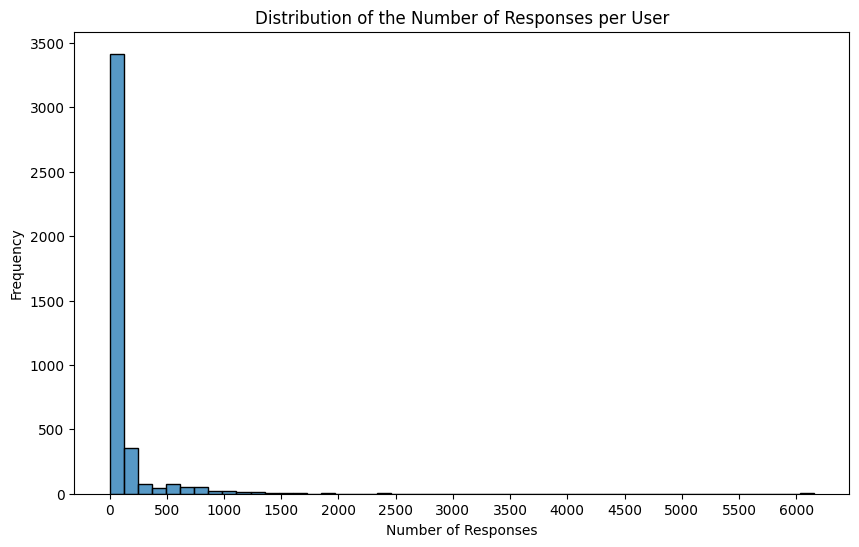

In [46]:
user_counts = df_answers_pivot['user_id'].value_counts()

plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=50, kde=False)
plt.title('Distribution of the Number of Responses per User')
plt.xlabel('Number of Responses')
plt.ylabel('Frequency')
plt.xticks(range(0, max(user_counts), 500))  # Adjust range and step as needed

plt.show()


In [47]:
len_before = len(df_answers_pivot)

df_filtered_user = df_answers_pivot.groupby('user_id').filter(lambda x: len(x) >= min_user_sequence_len)

# Then, for each user_id, keep only the first max_user_sequence_len rows
df_answers_valid_user = df_filtered_user.groupby('user_id').head(max_user_sequence_len)

# Display the filtered DataFrame
len_after = len(df_answers_valid_user)
diff = len_before - len_after

print(f"{len_after} rows kept out for {len_before}, meaning that {diff} rows were dropped.")


297620 rows kept out for 433671, meaning that 136051 rows were dropped.


## 4.3) Filtering out invalid skills

### 4.3.1) Filtering based on occurences

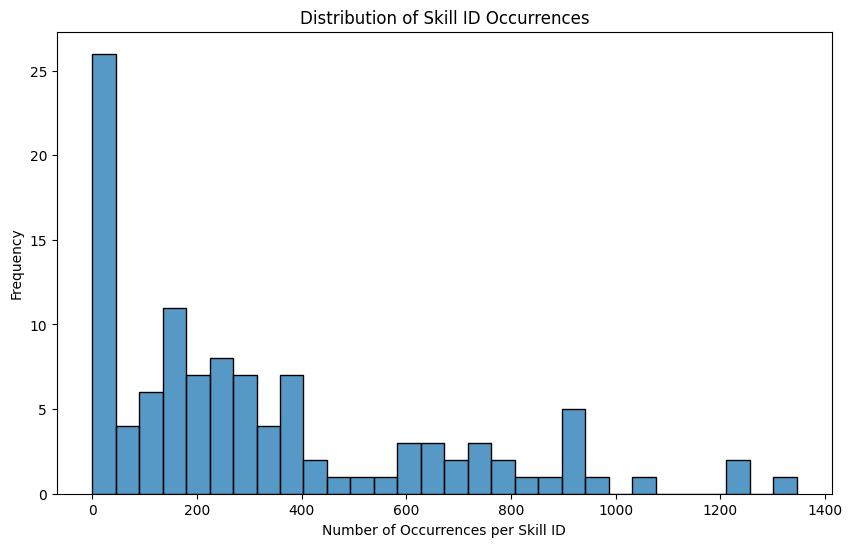

In [48]:
# Step 1: Count occurrences for each skill ID (sum the binary columns)
num_non_skill_columns = len(columns_to_keep)
skill_occurrences = df_answers_valid_user.groupby('user_id').max().iloc[:, num_non_skill_columns-1:].sum()

# Step 2: Plot a histogram of occurrences per skill
plt.figure(figsize=(10, 6))
sns.histplot(skill_occurrences, bins=30, kde=False)  # Adjust bins as needed
plt.title('Distribution of Skill ID Occurrences')
plt.xlabel('Number of Occurrences per Skill ID')
plt.ylabel('Frequency')
plt.show()


Let's have a closer look.

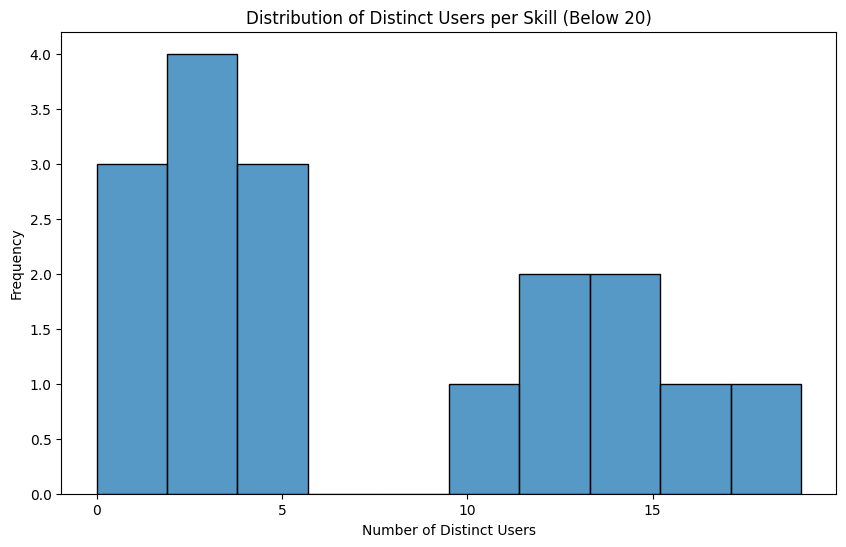

In [49]:
max_threshold = 20

skill_occurrences_below_th = skill_occurrences[skill_occurrences < max_threshold]
plt.figure(figsize=(10, 6))
sns.histplot(skill_occurrences_below_th, bins=10, kde=False)
plt.title(f'Distribution of Distinct Users per Skill (Below {max_threshold})')
plt.xlabel('Number of Distinct Users')
plt.ylabel('Frequency')
plt.xticks(range(0, max(skill_occurrences_below_th), 5))  # Adjust range and step as needed

plt.show()

In [50]:
len_before = len(df_answers_valid_user)

# Step 1: Identify skill_ids with less than 10 unique users
skills_to_remove = skill_occurrences[skill_occurrences < min_user_per_skill].index

# Step 2: Remove these skill_ids from the DataFrame
df_answers_valid_skills = df_answers_valid_user[[col for col in df_answers_valid_user.columns if col not in skills_to_remove]]
# Keep only rows where the sum of skill columns is not 0
df_answers_valid_skills = df_answers_valid_skills[df_answers_valid_skills.iloc[:, num_non_skill_columns:].sum(axis=1) != 0]

# Confirm the change by checking the number of unique skill_ids left
# Display the filtered DataFrame
len_after = len(df_answers_valid_skills)
diff = len_before - len_after

print(f"{len_after} rows kept out for {len_before}, meaning that {diff} rows were dropped.")


297411 rows kept out for 297620, meaning that 209 rows were dropped.


### 4.3.2) Filtering based on if they have a long enough sequence

For each skill we need at least one sequence, which has a length of at least a given value, e.g., 5. Otherwise we do not have long enough sequences to able to teach the model how such a skill is learnt.

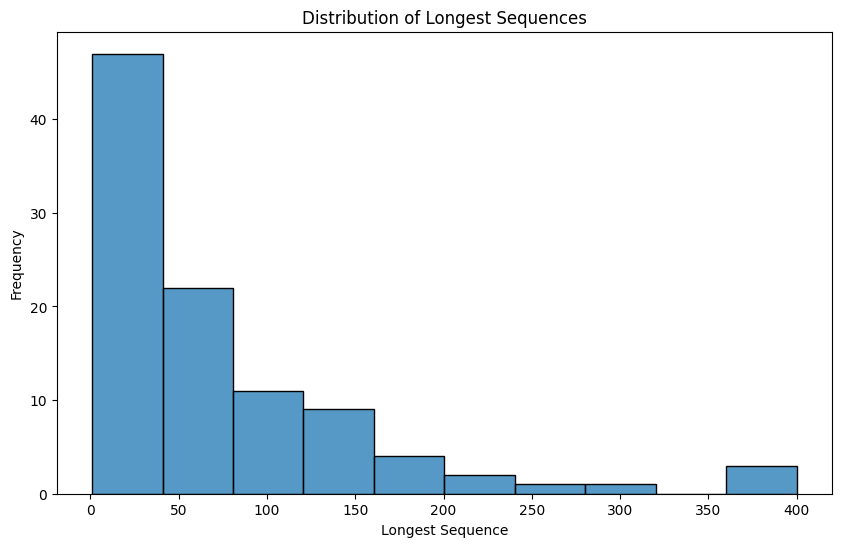

In [51]:
# Step 1: Count how many times each user_id appears for each skill_id
user_skill_counts = df_answers_valid_skills.groupby('user_id').sum()

# Step 2: Find the maximum user_count for each skill_id
max_skill_counts = user_skill_counts.iloc[:, num_non_skill_columns-1:].max()

plt.figure(figsize=(10, 6))
sns.histplot(max_skill_counts, bins=10, kde=False)
plt.title('Distribution of Longest Sequences')
plt.xlabel('Longest Sequence')
plt.ylabel('Frequency')

plt.show()

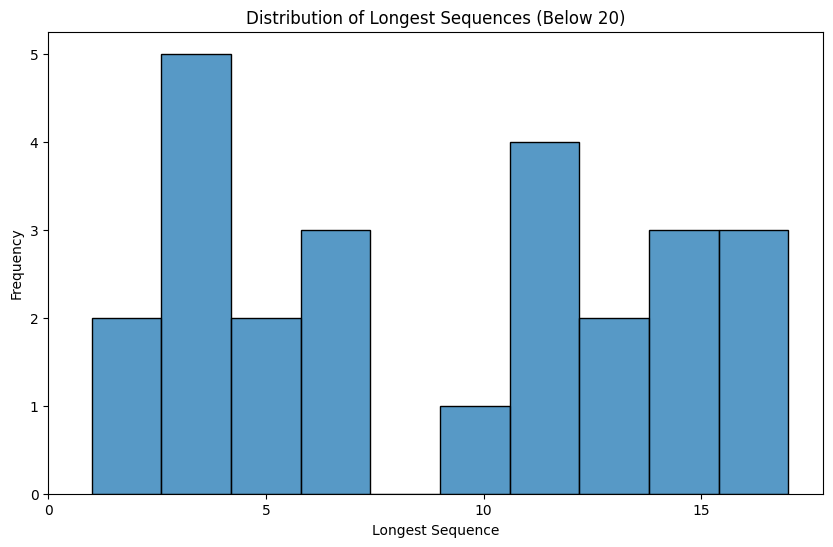

In [52]:
max_threshold = 20

max_skill_counts_below_th = max_skill_counts[max_skill_counts < max_threshold]
plt.figure(figsize=(10, 6))
sns.histplot(max_skill_counts_below_th, bins=10, kde=False)
plt.title(f'Distribution of Longest Sequences (Below {max_threshold})')
plt.xlabel('Longest Sequence')
plt.ylabel('Frequency')
plt.xticks(range(0, max(max_skill_counts_below_th), 5))  # Adjust range and step as needed

plt.show()

In [53]:
len_before = len(df_answers_valid_user)

# Step 1: Identify skill_ids with less than 10 unique users
skills_to_remove = max_skill_counts[max_skill_counts < min_len_longest_seq].index

# Step 2: Remove these skill_ids from the DataFrame
df_answers_valid_skills = df_answers_valid_skills[[col for col in df_answers_valid_skills.columns if col not in skills_to_remove]]
# Keep only rows where the sum of skill columns is not 0
df_answers_valid_skills = df_answers_valid_skills[df_answers_valid_skills.iloc[:, num_non_skill_columns:].sum(axis=1) != 0]

# Confirm the change by checking the number of unique skill_ids left
# Display the filtered DataFrame
len_after = len(df_answers_valid_skills)
diff = len_before - len_after

print(f"{len_after} rows kept out for {len_before}, meaning that {diff} rows were dropped.")

297396 rows kept out for 297620, meaning that 224 rows were dropped.


## 4.4) Checking the filterings

We have to check if a later filtering corrupted an earlier condition, hence we pack the filterings inside a function and do it until it does not have any effects.

In [54]:
user_counts = df_answers_valid_skills['user_id'].value_counts()
print(f"The minimum #appearances of a user: {user_counts.min()}")
print(f"The maximum #appearances of a user: {user_counts.max()}")

skill_occurrences = df_answers_valid_skills.groupby('user_id').max().iloc[:, num_non_skill_columns-1:].sum()  # Assuming binary skill columns start from 3rd column onward
print(f"The minimum #appearances amongst the skills: {skill_occurrences.min()}")

user_skill_counts = df_answers_valid_skills.groupby('user_id').sum()
max_skill_counts = user_skill_counts.iloc[:, num_non_skill_columns-1:].max()
print(f"The minimum longest sequence length amongst the skills: {max_skill_counts.min()}")


The minimum #appearances of a user: 2
The maximum #appearances of a user: 400
The minimum #appearances amongst the skills: 11
The minimum longest sequence length amongst the skills: 2


The minimal number of a user appearance decreased to 3, but it is still something we can work with, hence we do not perform any further cleaning steps.

# 5) Additional features


## 5.1) Handling feature 'ms_first_response

In [55]:
df_answers_valid_skills['ms_first_response'].describe()

count    2.973960e+05
mean     5.176923e+04
std      3.406113e+05
min     -8.423730e+05
25%      9.875000e+03
50%      2.331800e+04
75%      5.355525e+04
max      8.407692e+07
Name: ms_first_response, dtype: float64

In [56]:
# Top 20 largest values
print("Top 20 largest values:")
print(df_answers_valid_skills['ms_first_response'].nlargest(20))


Top 20 largest values:
345321    84076920
249476    74563450
236614    66158290
246953    59446217
381114    44637627
334390    28814407
41262     24531620
51698     19254657
381187    16081302
381188    16081302
208093    15424453
208094    15424453
412167    15424453
412168    15424453
212601    14920385
415675    14920385
278239    14828445
381215    14476486
381216    14476486
313287    14422416
Name: ms_first_response, dtype: int64


In [57]:
# Top 10 lowest values
print("\nTop 10 lowest values:")
print(df_answers_valid_skills['ms_first_response'].nsmallest(10))



Top 10 lowest values:
332673   -842373
332660   -800125
162532   -314441
11095      -4078
24134          0
24135          0
24136          0
24137          0
24144          0
24145          0
Name: ms_first_response, dtype: int64


There seem to be some extremely large values, so we clip these outliers.

Also, there cannot be negative values, so it is clipped at zero as well.

In [58]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_answers_valid_skills['ms_first_response'].quantile(0.25)
Q3 = df_answers_valid_skills['ms_first_response'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Calculate the lower and upper bounds using a multiplier of 3
upper_bound = Q3 + 3 * IQR

df_answers_valid_skills['ms_first_response'] = df_answers_valid_skills['ms_first_response'].clip(upper=upper_bound)

df_answers_valid_skills['ms_first_response'] = df_answers_valid_skills['ms_first_response'].clip(lower=0)


Afterwards, the values are normalized.

In [59]:
df_answers_valid_skills['ms_first_response'] = (
    df_answers_valid_skills['ms_first_response'] / upper_bound
)

# Check the result
print(df_answers_valid_skills['ms_first_response'].describe())


count    297396.000000
mean          0.223406
std           0.249074
min           0.000000
25%           0.053495
50%           0.126319
75%           0.290121
max           1.000000
Name: ms_first_response, dtype: float64


## 5.2) Adding feature `ease`

In [60]:
# Calculate the ratio of correctly answered to total answers for each problem_id
correct_ratios = df_answers_valid_skills.groupby('problem_id')['correct'].mean()

# Map the correct ratio to a new column in the original DataFrame
df_answers_valid_skills['ease'] = df_answers_valid_skills['problem_id'].map(correct_ratios)

cols = list(df_answers_valid_skills.columns)
cols.insert(5, cols.pop(cols.index('ease')))  # Adjust '1' to place it where you want
df_answers_valid_skills = df_answers_valid_skills[cols]

## 6) Comparing the Data

## 6.1) Final values

In [61]:
num_users = len(df_answers_valid_skills['user_id'].unique())
num_skills = len(df_answers_valid_skills.columns) - num_non_skill_columns - 1
num_answers = len(df_answers_valid_skills)
print(f'Number of users: {num_users}')
print(f'Number of skills: {num_skills}')
print(f'Number of answers: {num_answers}')


Number of users: 4008
Number of skills: 99
Number of answers: 297396


## 6.2) Original values

In [63]:
num_users_og = len(df_data['user_id'].unique())
num_skills_og = len(df_data['skill_id'].unique())
num_answers_og = len(df_data)
print(f'Number of original users: {num_users_og}')
print(f'Number of original skills: {num_skills_og}')
print(f'Number of original answers: {num_answers_og}')

Number of original users: 4217
Number of original skills: 124
Number of original answers: 525534


We automatize these cleaning steps in the `src/clean_assitments_data.py` script.